# imports

In [ ]:
import torchimport torchvisionfrom torch import nnimport torchvision.transforms as transformsfrom tqdm.auto import tqdmimport warningsfrom timeit import default_timer as timerimport pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import confusion_matrixwarnings.filterwarnings('ignore')

## using CUDA

In [192]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Timer

In [193]:
def print_train_time(start: float, end : float, device: torch.device = None):    total_time = end - start    print(f"Train time on {device}: {total_time/60:.3f} minutes\n\n")    return total_time

## Transforming to Tensors

In [194]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

In [195]:
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

## 'Train', 'Validation', 'Test'

In [196]:
train_size = int(0.8 * len(trainset))val_size = len(trainset) - train_sizetrain_subset, val_subset = torch.utils.data.random_split(trainset, [train_size, val_size])# Create DataLoaders for each settrainloader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)valloader = torch.utils.data.DataLoader(val_subset, batch_size=64, shuffle=False)testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

## Deep Neural Network

In [197]:
class DeepNN(nn.Module):    def __init__(self, input_features=784, output_features=10, hidden_features=104, init_method=None):        super().__init__()        self.layer_stack = nn.Sequential(            nn.Linear(in_features=input_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=output_features),        )        self._initialize_weights(init_method)    def _initialize_weights(self, init_method):        if init_method != None:            for layer in self.layer_stack:                if isinstance(layer, nn.Linear):                    if init_method == 'he':                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')                    elif init_method == 'xavier':                        nn.init.xavier_normal_(layer.weight)                    elif init_method == 'random':                        nn.init.normal_(layer.weight, mean=0, std=1)                    nn.init.zeros_(layer.bias)  # Initialize biases to zero    def forward(self, x):        return self.layer_stack(x)

## Wide Nerual Network

In [198]:
class WideNN(nn.Module):    def __init__(self, input_features=784, output_features=10, hidden_features=136, init_method=None):        super().__init__()        self.layer_stack = nn.Sequential(            nn.Linear(in_features=input_features, out_features=hidden_features),            nn.ReLU(),            nn.Linear(in_features=hidden_features, out_features=output_features),        )        self._initialize_weights(init_method)    def _initialize_weights(self, init_method):        if init_method != None:            for layer in self.layer_stack:                if isinstance(layer, nn.Linear):                    if init_method == 'he':                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')                    elif init_method == 'xavier':                        nn.init.xavier_normal_(layer.weight)                    elif init_method == 'random':                        nn.init.normal_(layer.weight, mean=0, std=1)                    nn.init.zeros_(layer.bias)  # Initialize biases to zero    def forward(self, x):        return self.layer_stack(x)

In [199]:
deep_model = DeepNN().to(device)wide_model = WideNN().to(device)

In [ ]:
print(f"Deep_model state_dict {deep_model.state_dict}")print(f"Wide_model state_dict {wide_model.state_dict}")

Deep_model state_dict <bound method Module.state_dict of DeepNN(
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=104, bias=True)
    (1): ReLU()
    (2): Linear(in_features=104, out_features=104, bias=True)
    (3): ReLU()
    (4): Linear(in_features=104, out_features=104, bias=True)
    (5): ReLU()
    (6): Linear(in_features=104, out_features=104, bias=True)
    (7): ReLU()
    (8): Linear(in_features=104, out_features=10, bias=True)
  )
)>
Deep_model state_dict <bound method Module.state_dict of WideNN(
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=136, bias=True)
    (1): ReLU()
    (2): Linear(in_features=136, out_features=10, bias=True)
  )
)>


## 'Loss' and 'Optimizer'

In [201]:
deep_loss = nn.CrossEntropyLoss()wide_loss = nn.CrossEntropyLoss()deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.001)wide_optimizer = torch.optim.Adam(wide_model.parameters(), lr=0.001)

## "Train" and "Evaluation" Loop

In [ ]:
def train_and_evaluate(model, trainloader, valloader, loss_fn, optimizer, device, epochs=8):    start_time = timer()    train_losses = []    eval_losses = []    for epoch in range(epochs):        model.train()        train_loss = 0        for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} - Training"):            images, labels = images.to(device), labels.to(device)            images = images.flatten(start_dim=1)            outputs = model(images)            loss = loss_fn(outputs, labels)            optimizer.zero_grad()            loss.backward()            optimizer.step()            train_loss += loss.item()        avg_train_loss = train_loss/len(trainloader)        train_losses.append(avg_train_loss)        print(f" ** Training Loss: {avg_train_loss:.4f}")        model.eval()        correct = 0        total = 0        eval_loss = 0        with torch.inference_mode():            for images, labels in tqdm(valloader, desc=f"Epoch {epoch+1}/{epochs} - Evaluation"):                images, labels = images.to(device), labels.to(device)                images = images.flatten(start_dim=1)                outputs = model(images)                predicted = torch.argmax(outputs, dim=1)                total += labels.size(0)                correct += (predicted == labels).sum().item()                loss = loss_fn(outputs, labels)  # Calculate evaluation loss                eval_loss += loss.item()        avg_eval_loss = eval_loss / len(valloader)        eval_losses.append(avg_eval_loss)        accuracy = 100 * correct / total        print(f" ** Evaluation Accuracy: {accuracy:.2f}%\n\n")    end_time = timer()    print_train_time(start_time, end_time, device=device)    return train_losses, eval_losses

## Evaluation on Test set

In [203]:
def testset_prediction(model, testloader, device):    model.eval()    all_preds = []    all_labels = []    correct = 0    total = 0    with torch.inference_mode():        for images, labels in tqdm(testloader, desc="Final Test Evaluation"):            images, labels = images.to(device), labels.to(device)            images = images.flatten(start_dim=1)            outputs = model(images)            predicted = torch.argmax(outputs, dim=1)            total += labels.size(0)            correct += (predicted == labels).sum().item()            all_preds.extend(predicted.cpu().numpy())            all_labels.extend(labels.cpu().numpy())    test_accuracy = 100 * correct / total    conf_matrix = confusion_matrix(all_labels, all_preds)    print(f"Final Test Accuracy: {test_accuracy:.2f}%")    return conf_matrix, test_accuracy

## visualizer

In [204]:
def plot_train_eval(train_losses, eval_losses, confusion_matrix):    fig, axes = plt.subplots(1, 2, figsize=(20, 10))    plt.sca(axes[0])    plt.plot(train_losses, label="Training Loss", marker='o')    plt.plot(eval_losses, label="Evaluation Loss", marker='s')    plt.xlabel("Epoch")    plt.ylabel("Loss")    plt.title("Training and Evaluation Loss")    plt.legend()    plt.sca(axes[1])    sns.heatmap(confusion_matrix.astype(int), vmin = 0, vmax = 1,center = 0, cmap='crest',  square = True, annot = True, cbar=False, linewidth=.5, fmt='d',                annot_kws={"size": 18,})    plt.title("Confusion Matrix", fontsize=8)    plt.tight_layout()    plt.show()

## Deep Model (train, evaluation, test) + Visualization

In [205]:
deep_train_loss, deep_eval_loss = train_and_evaluate(model=deep_model, trainloader=trainloader, valloader=valloader, loss_fn=deep_loss, optimizer=deep_optimizer, device=device, epochs=10)deep_Adam_cm, deep_Adam_acc = testset_prediction(model=deep_model, testloader=testloader, device=device)

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:43<00:00, 17.22it/s]


 ** Training Loss: 0.5888


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.36it/s]


 ** Evaluation Accuracy: 82.89%




...

 ** Training Loss: 0.2569


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.33it/s]


 ** Evaluation Accuracy: 87.97%


Train time on cuda: 8.896 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:07<00:00, 19.82it/s]

Final Test Accuracy: 87.43%


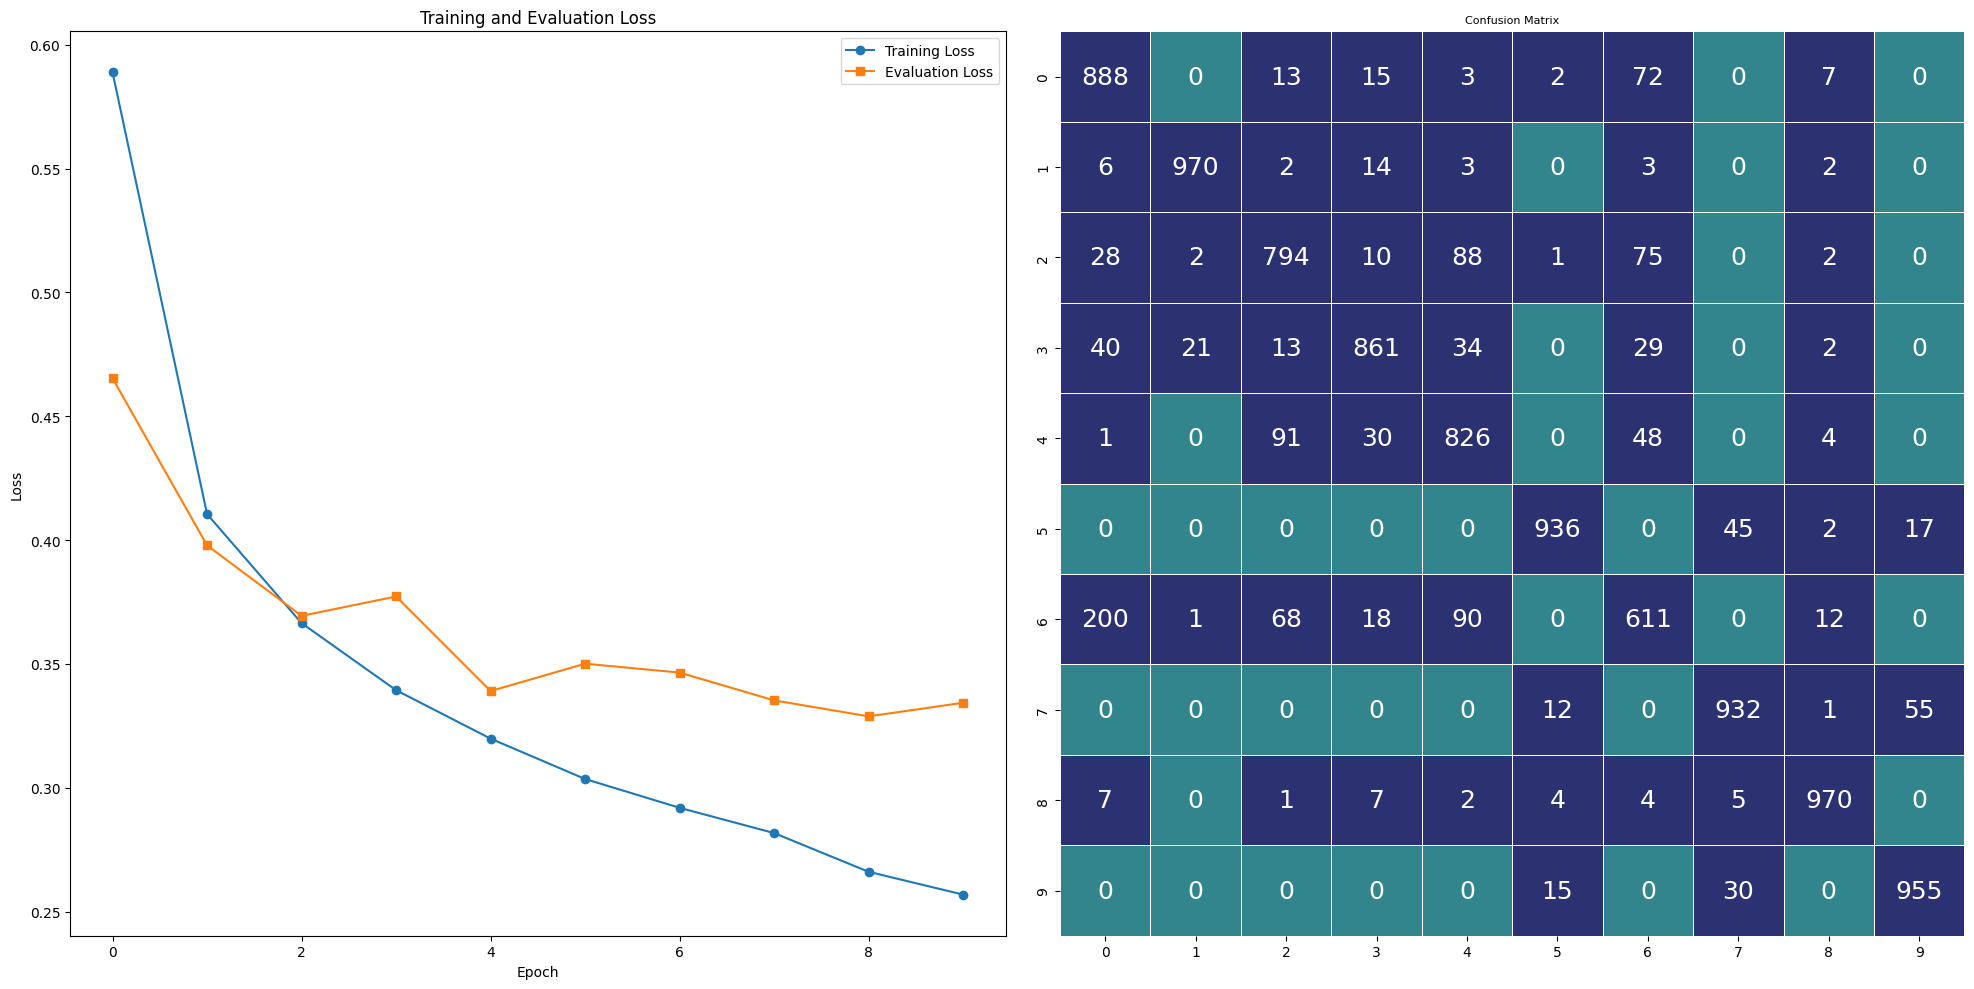

In [206]:
plot_train_eval(deep_train_loss, deep_eval_loss, deep_Adam_cm)

## Wide Model (train, evaluation, test) + Visualization

In [207]:
wide_train_loss, wide_eval_loss = train_and_evaluate(model=wide_model, trainloader=trainloader, valloader=valloader, loss_fn=wide_loss, optimizer=wide_optimizer, device=device, epochs=10)wide_Adam_cm, wide_Adam_acc = testset_prediction(model=wide_model, testloader=testloader, device=device)

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:39<00:00, 19.17it/s]


 ** Training Loss: 0.5154


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 21.63it/s]


 ** Evaluation Accuracy: 85.05%




Epoch 2/10 - Training: 100%|██████████| 750/750 [00:43<00:00, 17.41it/s]


...

 ** Training Loss: 0.2402


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:08<00:00, 22.41it/s]


 ** Evaluation Accuracy: 88.67%


Train time on cuda: 8.338 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:06<00:00, 22.89it/s]

Final Test Accuracy: 88.08%


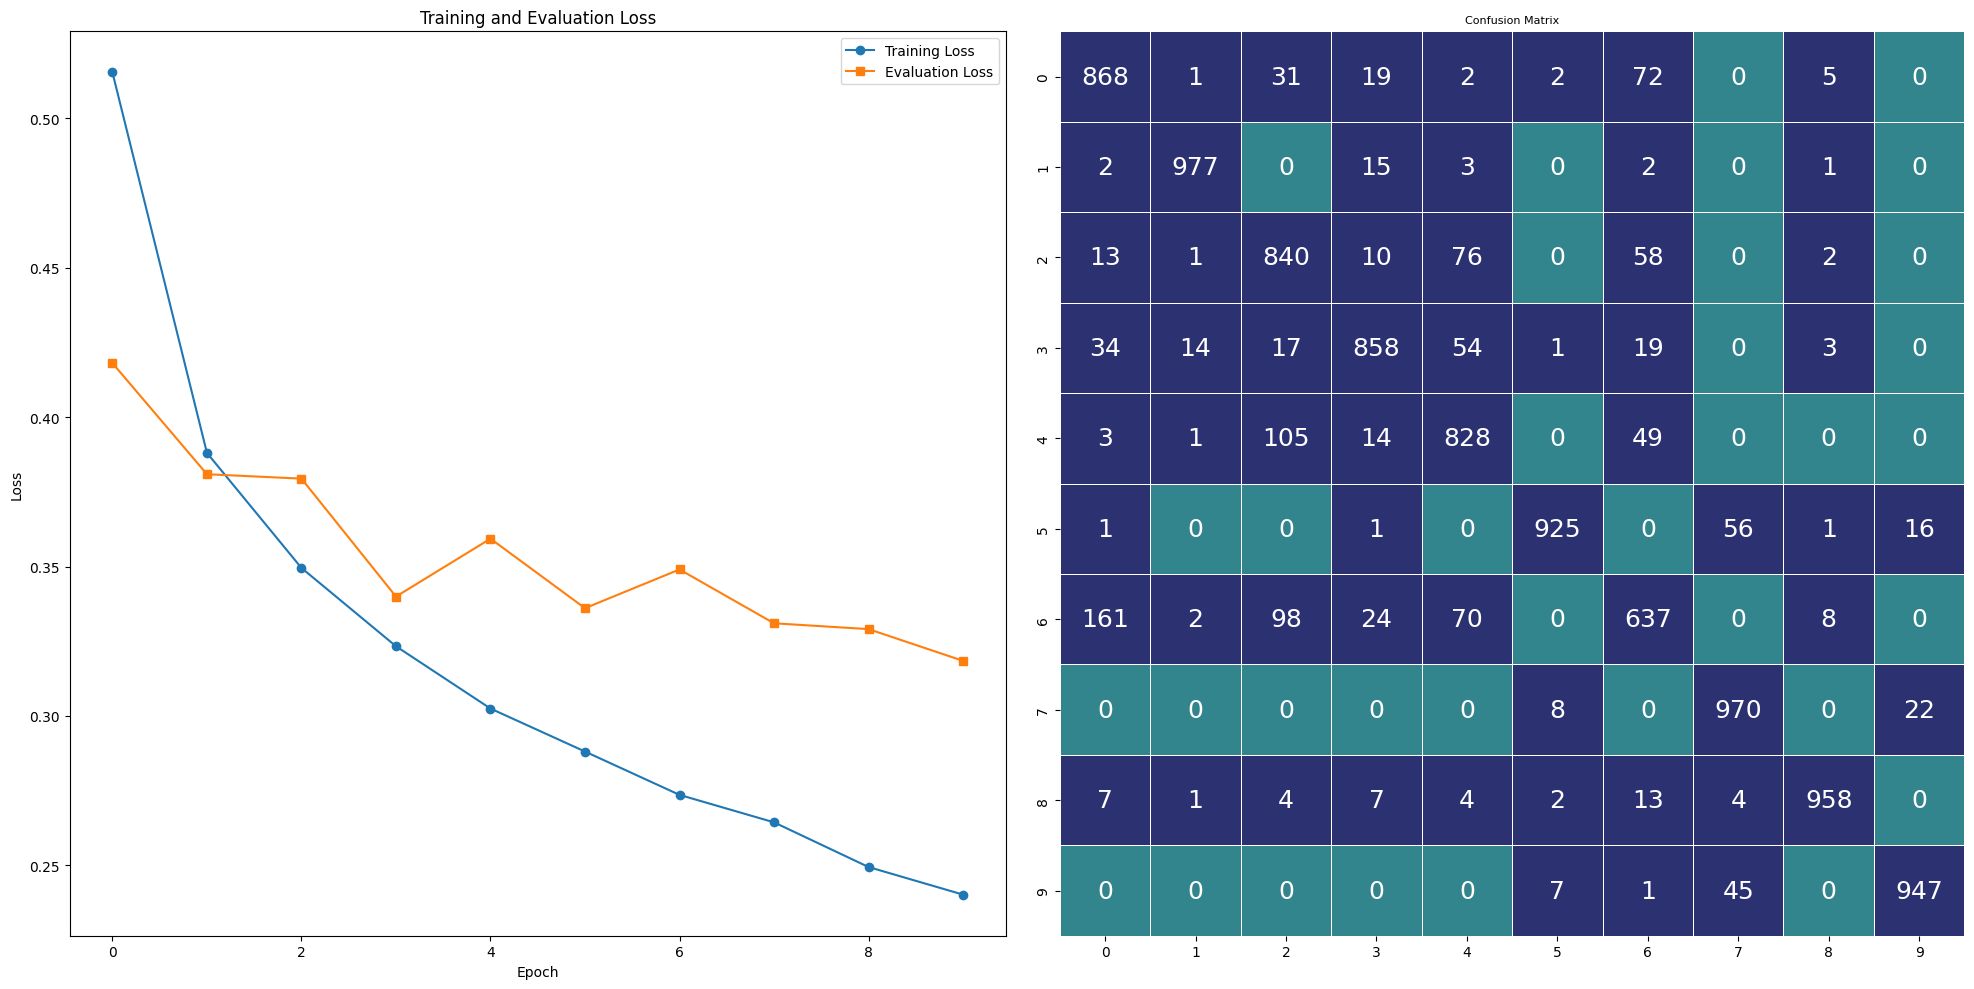

In [208]:
plot_train_eval(wide_train_loss, wide_eval_loss, wide_Adam_cm)

## Deep ("He" & "Xavier" & "Random")

Epoch 1/10 - Training:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/10 - Training: 100%|██████████| 750/750 [00:42<00:00, 17.59it/s]


 ** Training Loss: 0.5289


Epoch 1/10 - Evaluation: 100%|██████████| 188/188 [00:09<00:00, 20.06it/s]


 ** Evaluation Accuracy: 83.13%




...

 ** Training Loss: 110.1957


Epoch 10/10 - Evaluation: 100%|██████████| 188/188 [00:10<00:00, 18.33it/s]


 ** Evaluation Accuracy: 75.12%


Train time on cuda: 9.114 minutes




Final Test Evaluation: 100%|██████████| 157/157 [00:08<00:00, 18.57it/s]


Final Test Accuracy: 74.49%
Deep Neural Network ('He' weight initialization algorithm)


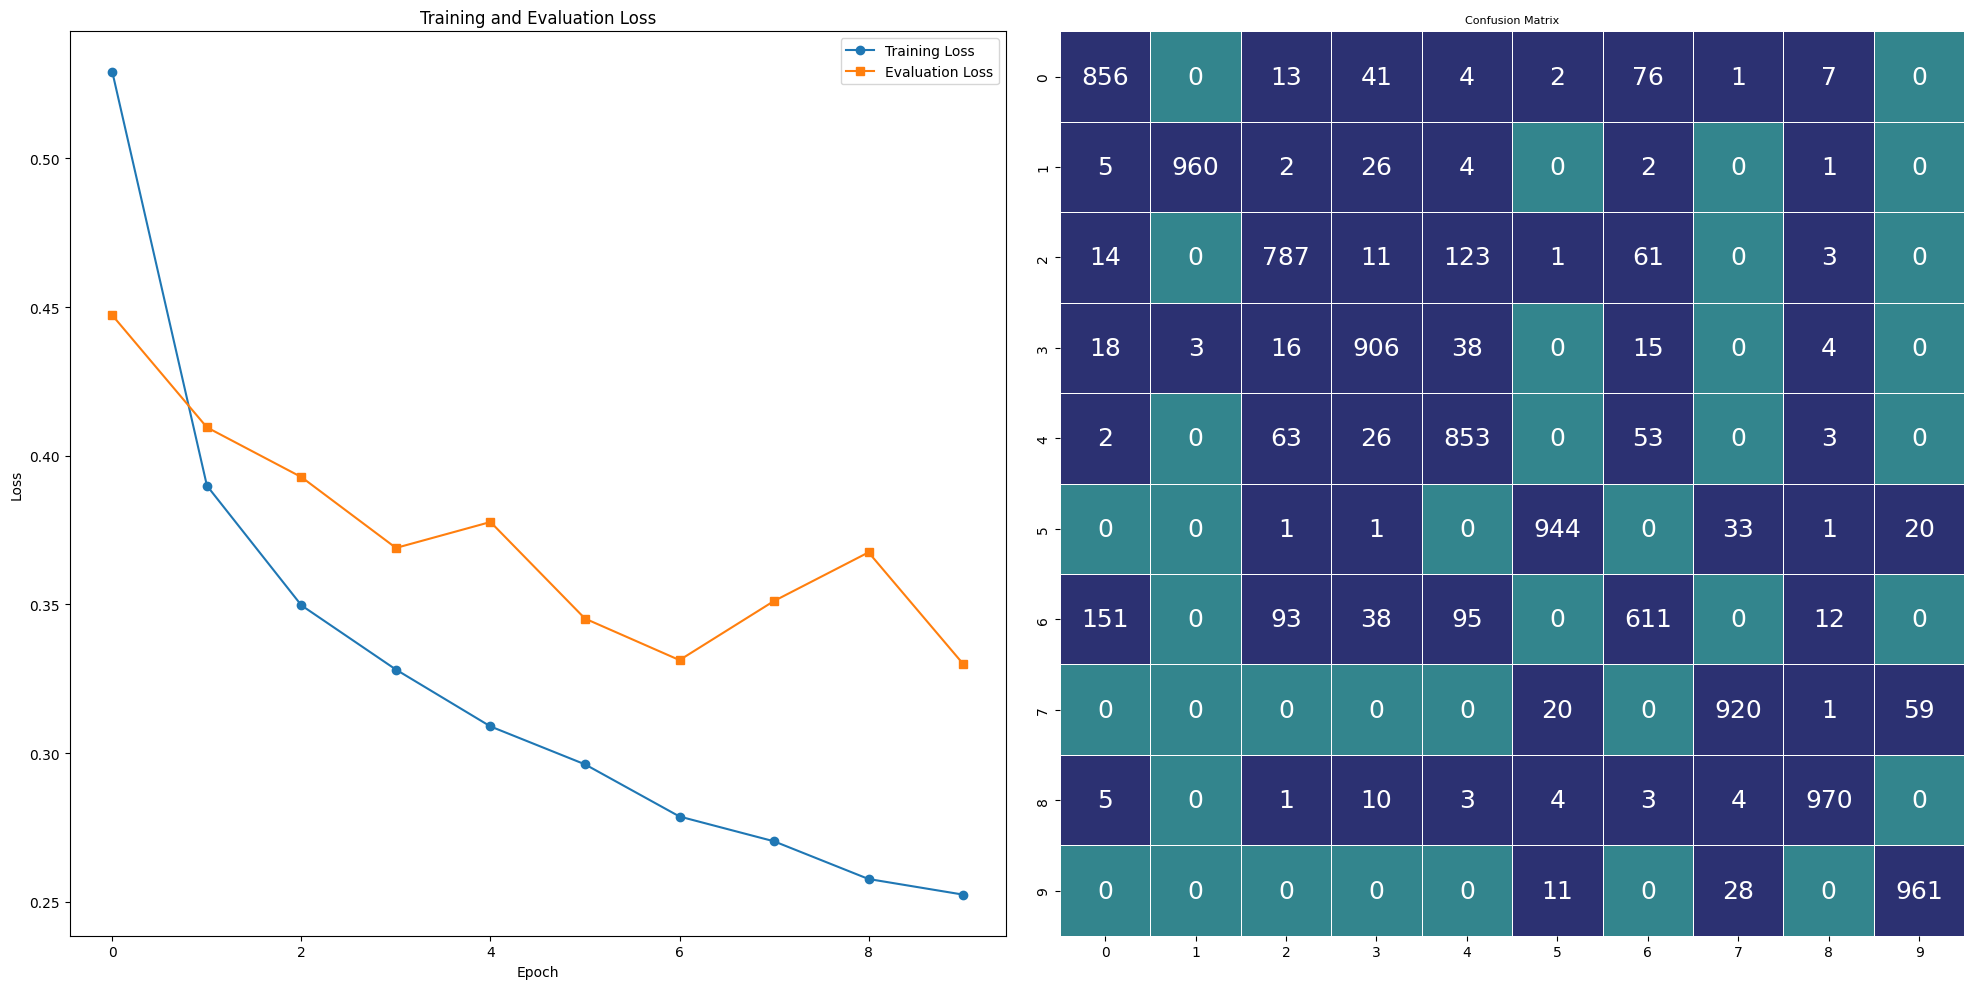

Deep Neural Network ('Xavier' weight initialization algorithm)


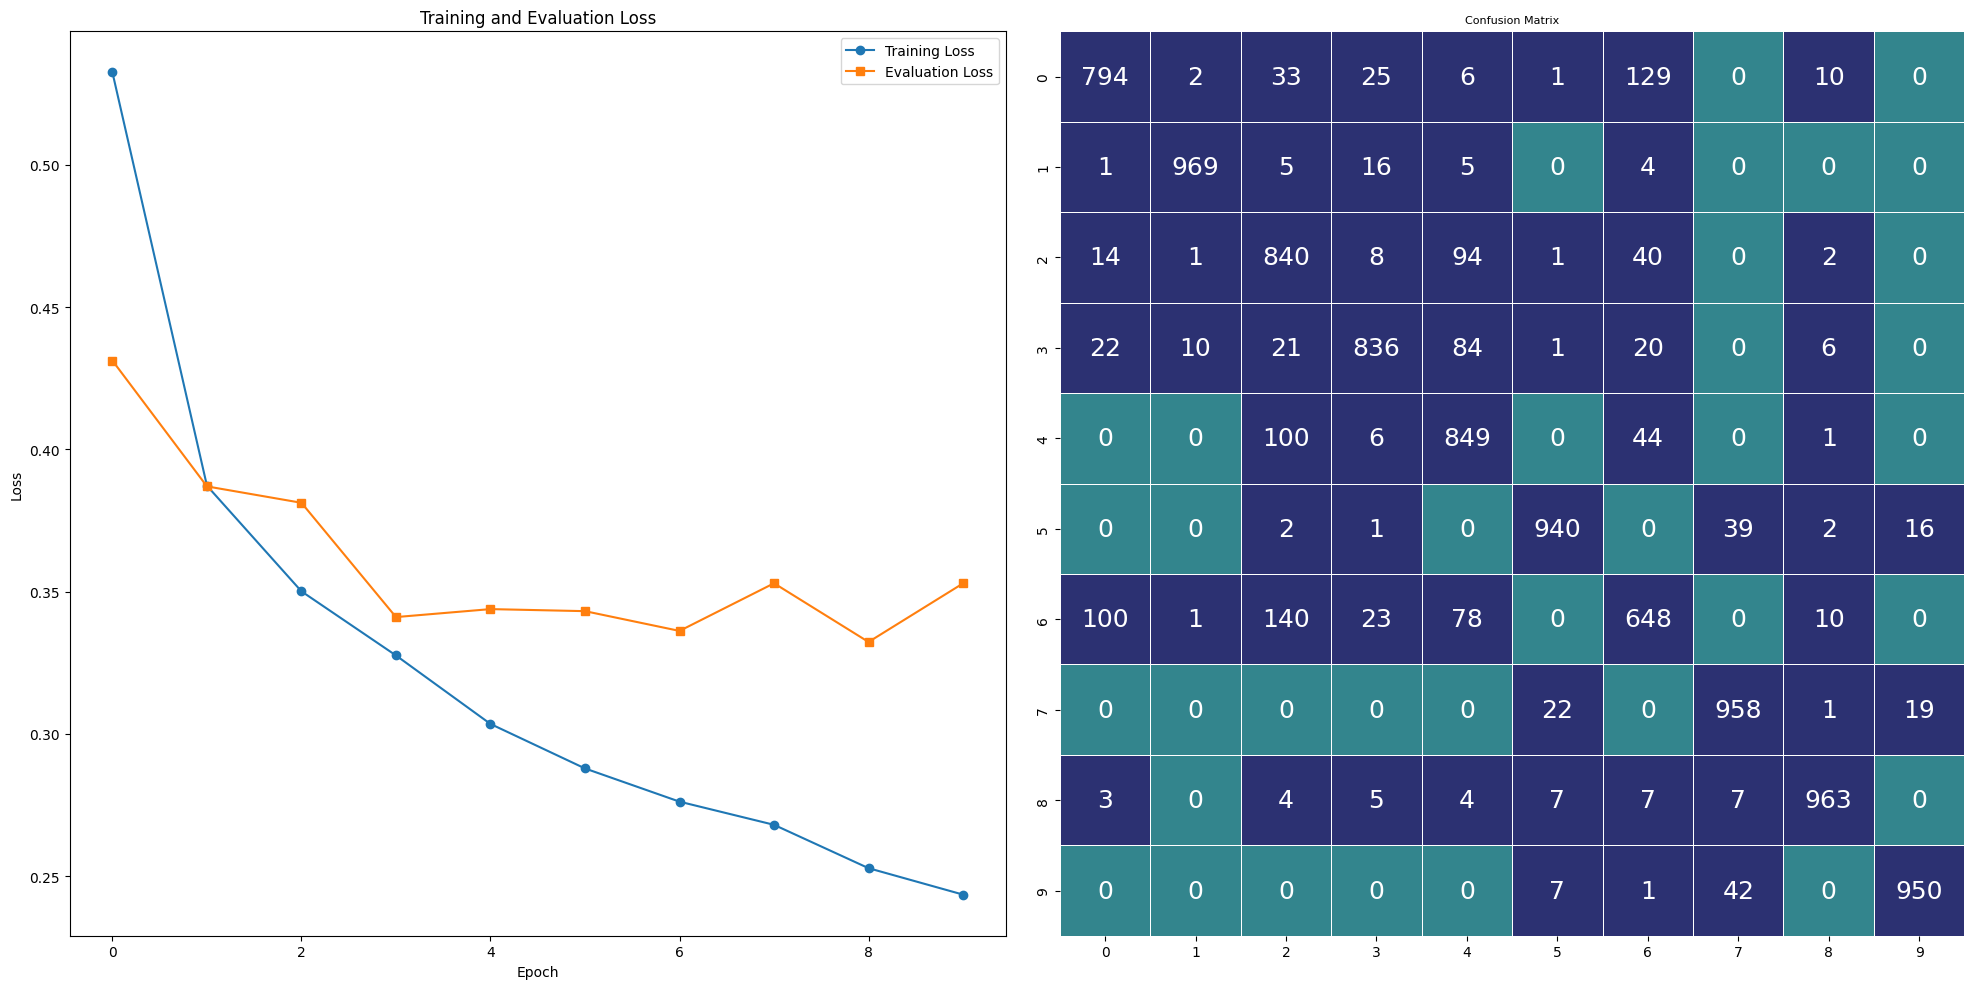

Deep Neural Network ('Random' weight initialization algorithm)


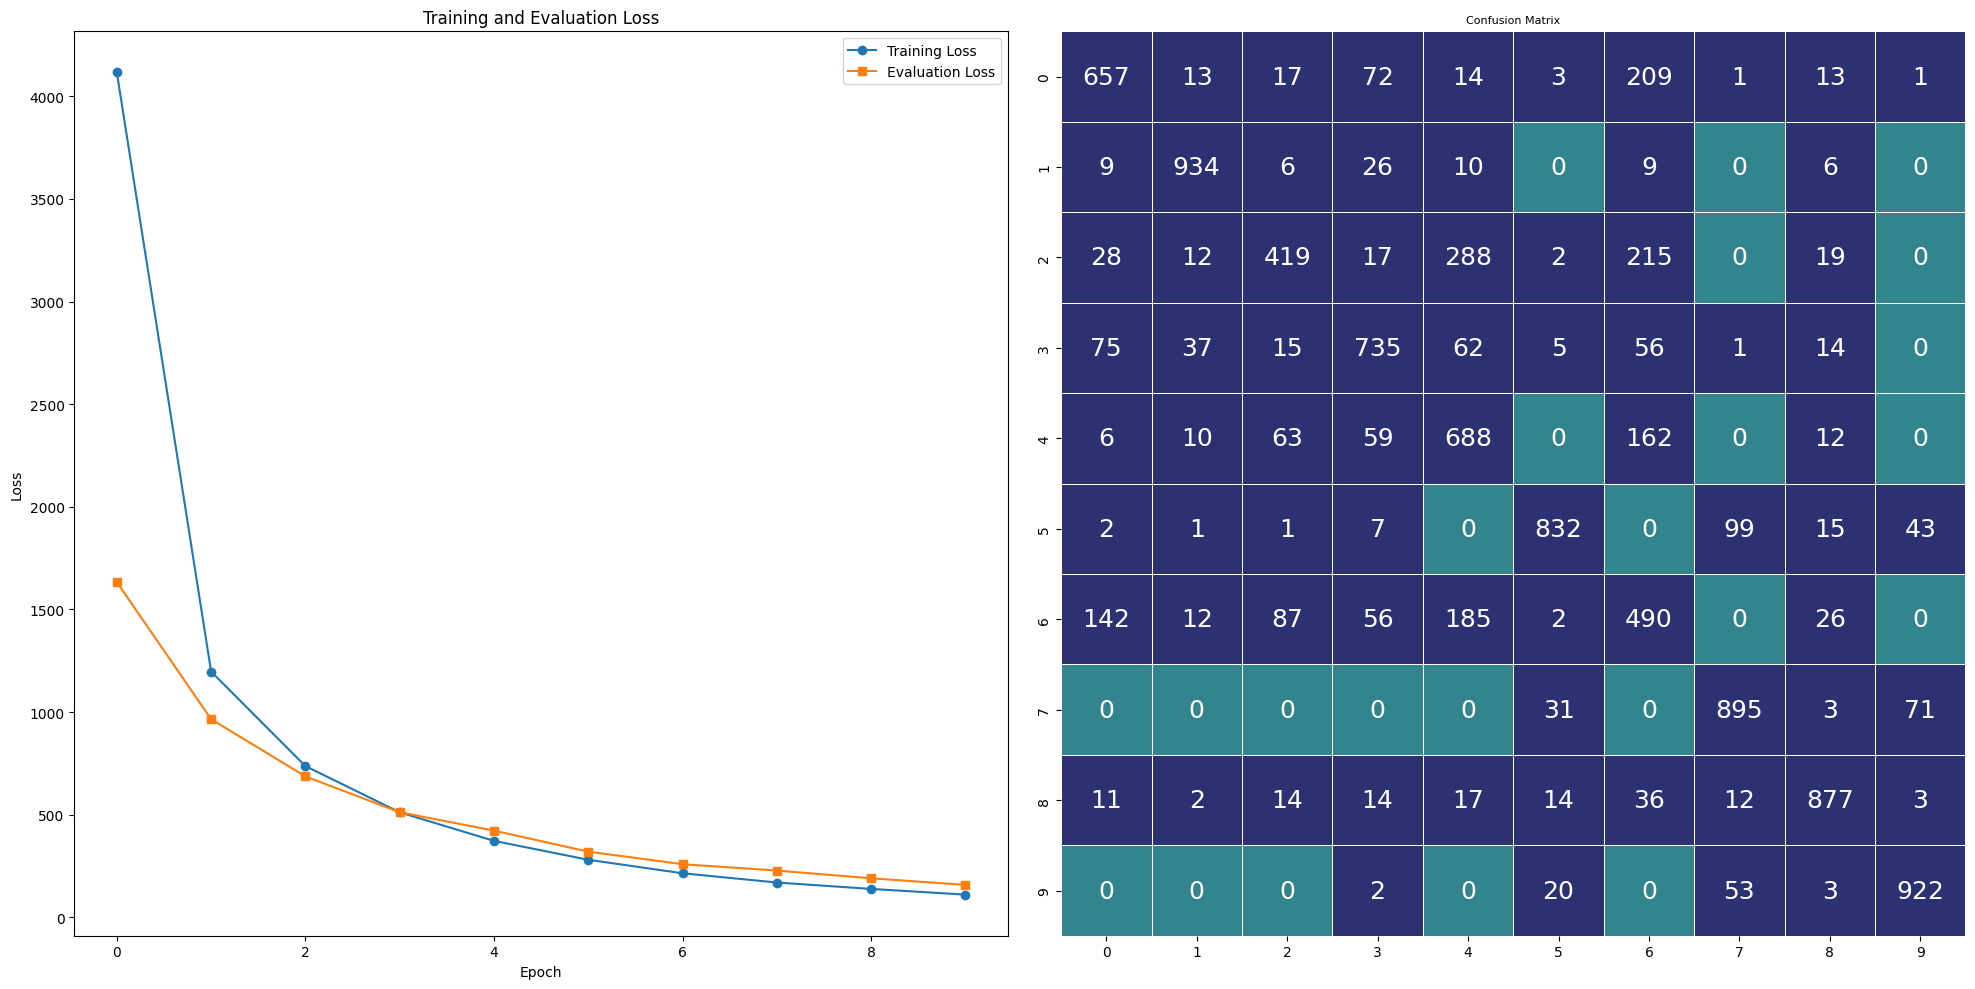

In [214]:
# Hedeep_model_he = DeepNN(init_method='he').to(device)deep_optimizer = torch.optim.Adam(deep_model_he.parameters(), lr=0.001)deep_he_train_loss, deep_he_eval_loss = train_and_evaluate(deep_model_he, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_he_cm, deep_he_acc = testset_prediction(deep_model_he, testloader, device)# Xavierdeep_model_xavier = DeepNN(init_method='xavier').to(device)deep_optimizer = torch.optim.Adam(deep_model_xavier.parameters(), lr=0.001)deep_Xavier_train_loss, deep_Xavier_eval_loss = train_and_evaluate(deep_model_xavier, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_Xavier_cm, deep_Xavier_acc = testset_prediction(deep_model_xavier, testloader, device)# Randomdeep_model_random = DeepNN(init_method='random').to(device)deep_optimizer = torch.optim.Adam(deep_model_random.parameters(), lr=0.001)deep_random_train_loss, deep_random_eval_loss = train_and_evaluate(deep_model_random, trainloader, valloader, deep_loss, deep_optimizer, device, epochs=10)deep_random_cm, deep_random_acc = testset_prediction(deep_model_random, testloader, device)print("Deep Neural Network ('He' weight initialization algorithm)")plot_train_eval(deep_he_train_loss, deep_he_eval_loss, deep_he_cm)print("Deep Neural Network ('Xavier' weight initialization algorithm)")plot_train_eval(deep_Xavier_train_loss, deep_Xavier_eval_loss, deep_Xavier_cm)print("Deep Neural Network ('Random' weight initialization algorithm)")plot_train_eval(deep_random_train_loss, deep_random_eval_loss, deep_random_cm)